In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: better plot style
sns.set_theme(style="whitegrid")

In [31]:
df = pd.read_csv("../data/processed/race_driver_labels.csv")

df.columns

Index(['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder',
       'points', 'statusId', 'year', 'round', 'circuitId', 'raceName',
       'qualifyingPosition', 'avgLapTime_ms', 'minLapTime_ms', 'lapsCompleted',
       'pitStopCount', 'avgPitDuration_ms', 'driverName_x',
       'constructorName_x', 'driverName_y', 'constructorName_y', 'driverName',
       'constructorName', 'finishPosition', 'avgLapTime_s',
       'constructorPoints'],
      dtype='object')

In [32]:
df["positionOrder"].isna().sum()
finish_positions = df["finishPosition"].dropna()
finish_positions = finish_positions.astype(int)

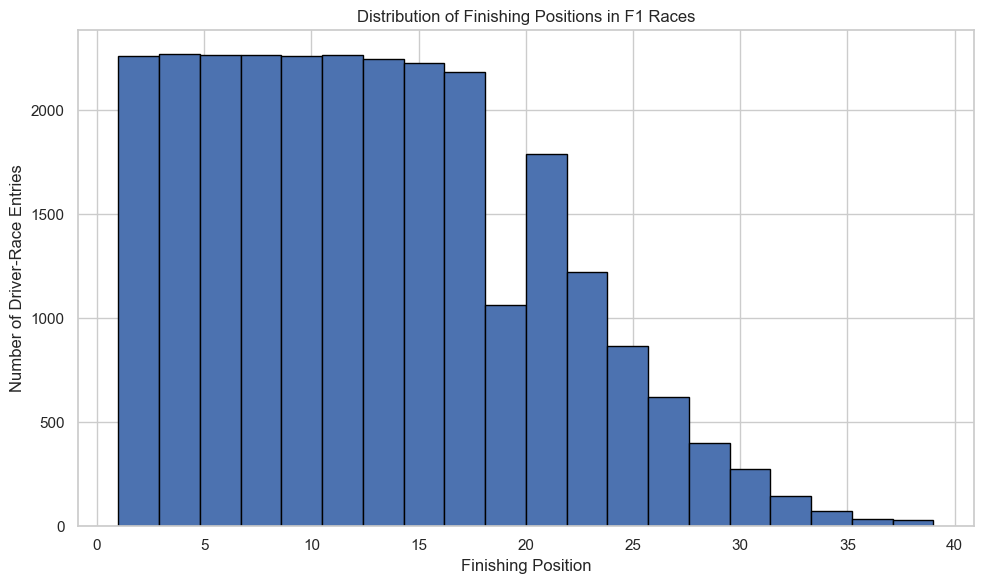

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(
    finish_positions,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Finishing Position")
plt.ylabel("Number of Driver-Race Entries")
plt.title("Distribution of Finishing Positions in F1 Races")

plt.tight_layout()
plt.savefig("../report/figures/finish_position_histogram.png")
plt.show()

Interpretation:
The distribution of finishing positions is highly skewed toward lower-ranked positions, with many more observations in mid-to-backfield finishes than podium positions. This reflects the limited number of top finishing slots per race and suggests that predicting exact finishing position is a challenging regression task. This insight motivates exploring rank-based or grouped prediction strategies in later modeling stages.

In [35]:
print(df[["qualifyingPosition", "finishPosition"]].isna().sum())

qualifyingPosition    16265
finishPosition            0
dtype: int64


In [36]:
scatter_df = df[
    (df["qualifyingPosition"].notna()) &
    (df["finishPosition"].notna()) &
    (df["qualifyingPosition"] > 0) &
    (df["finishPosition"] > 0)
].copy()

scatter_df["qualifyingPosition"] = scatter_df["qualifyingPosition"].astype(int)
scatter_df["finishPosition"] = scatter_df["finishPosition"].astype(int)


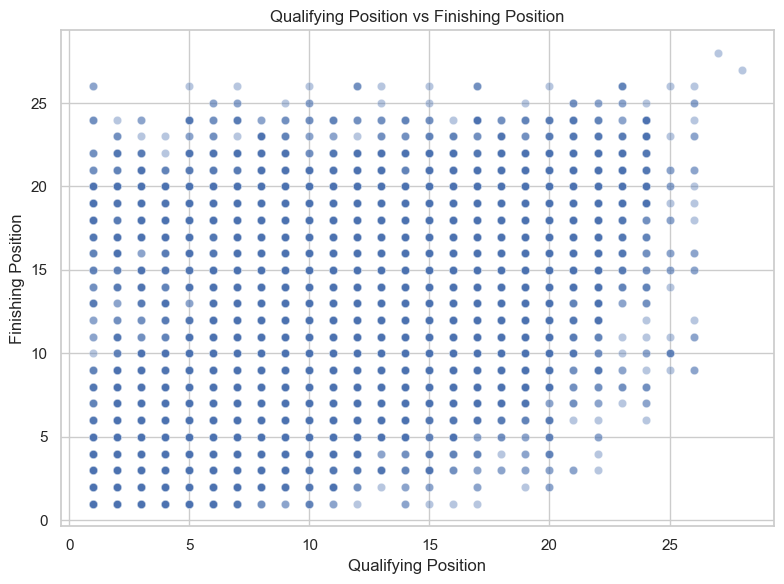

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=scatter_df,
    x="qualifyingPosition",
    y="finishPosition",
    alpha=0.4
)

plt.title("Qualifying Position vs Finishing Position")
plt.xlabel("Qualifying Position")
plt.ylabel("Finishing Position")

plt.tight_layout()
plt.savefig("../report/figures/qualifying_vs_finish.png", dpi=300)
plt.show()


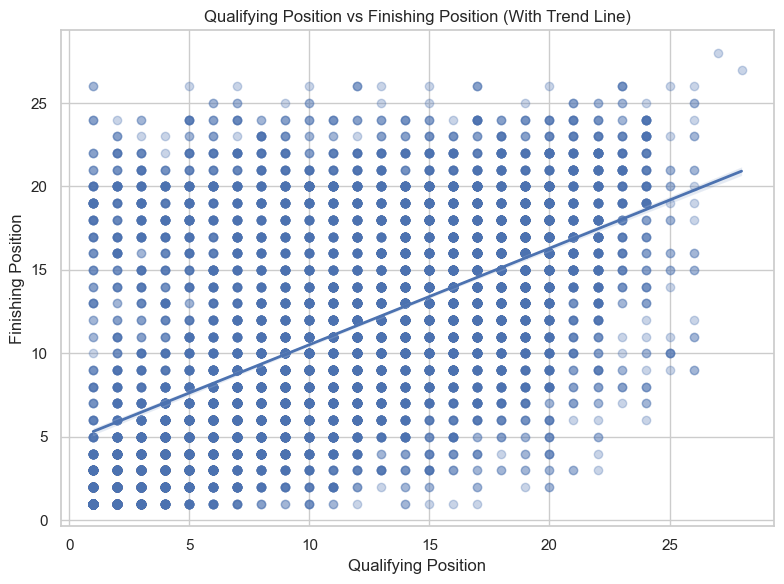

In [38]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=scatter_df,
    x="qualifyingPosition",
    y="finishPosition",
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2}
)

plt.title("Qualifying Position vs Finishing Position (With Trend Line)")
plt.xlabel("Qualifying Position")
plt.ylabel("Finishing Position")

plt.tight_layout()
plt.show()


The scatter plot shows a clear positive relationship between qualifying position and finishing position, indicating that drivers starting closer to the front tend to finish higher. However, the wide spread of points demonstrates significant race variability due to factors such as pit strategy, reliability, and race incidents. This justifies the use of machine learning models rather than deterministic rules.

Important Note:
Due to the discrete nature of Formula One positions and the large historical dataset spanning multiple decades, standard scatter plots exhibit overplotting. To improve interpretability, jittered and density-based visualisations should be used while preserving the underlying data distribution.

In [39]:
corr = scatter_df["qualifyingPosition"].corr(scatter_df["finishPosition"])
print(f"Pearson correlation: {corr:.3f}")

Pearson correlation: 0.576


In [40]:
df = pd.read_csv("../data/processed/race_driver_labels.csv")

df.columns

Index(['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder',
       'points', 'statusId', 'year', 'round', 'circuitId', 'raceName',
       'qualifyingPosition', 'avgLapTime_ms', 'minLapTime_ms', 'lapsCompleted',
       'pitStopCount', 'avgPitDuration_ms', 'driverName_x',
       'constructorName_x', 'driverName_y', 'constructorName_y', 'driverName',
       'constructorName', 'finishPosition', 'avgLapTime_s',
       'constructorPoints'],
      dtype='object')

In [41]:
df[["constructorName", "finishPosition"]].isna().sum()

constructorName    0
finishPosition     0
dtype: int64

In [42]:
constructor_perf = (
    df.dropna(subset=["constructorName", "finishPosition"])
      .groupby("constructorName")
      .agg(
          avgFinish=("finishPosition", "mean"),
          raceEntries=("finishPosition", "count")
      )
      .reset_index()
)

In [43]:
constructor_perf = constructor_perf[constructor_perf["raceEntries"] >= 100]

In [44]:
constructor_perf = constructor_perf.sort_values("avgFinish")

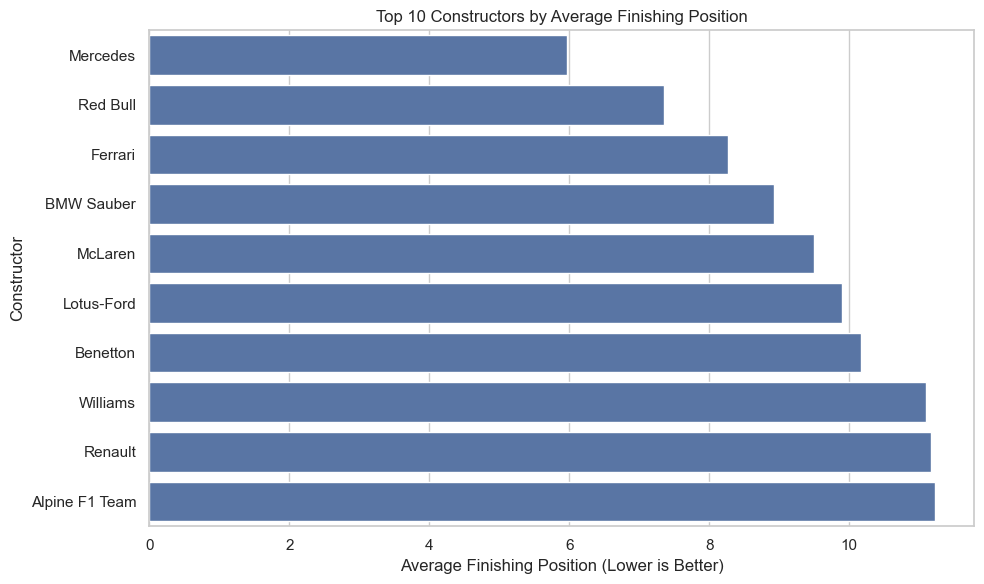

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=constructor_perf.head(10),
    x="avgFinish",
    y="constructorName"
)

plt.title("Top 10 Constructors by Average Finishing Position")
plt.xlabel("Average Finishing Position (Lower is Better)")
plt.ylabel("Constructor")

plt.tight_layout()
plt.savefig("../report/figures/top_constructors_avg_finish.png", dpi=300)
plt.show()

Interpretation:
The analysis shows strong performance differences between constructors, with top teams consistently achieving lower average finishing positions and higher points per race. This confirms that constructor identity is a critical explanatory feature and should be included in predictive models. The magnitude of performance gaps justifies modeling constructor effects explicitly rather than treating all drivers equally.

In [47]:
constructor_points = (
    df.dropna(subset=["constructorName", "constructorPoints"])
      .groupby("constructorName")
      .agg(
          avgPoints=("constructorPoints", "mean")
      )
      .reset_index()
      .sort_values("avgPoints", ascending=False)
)

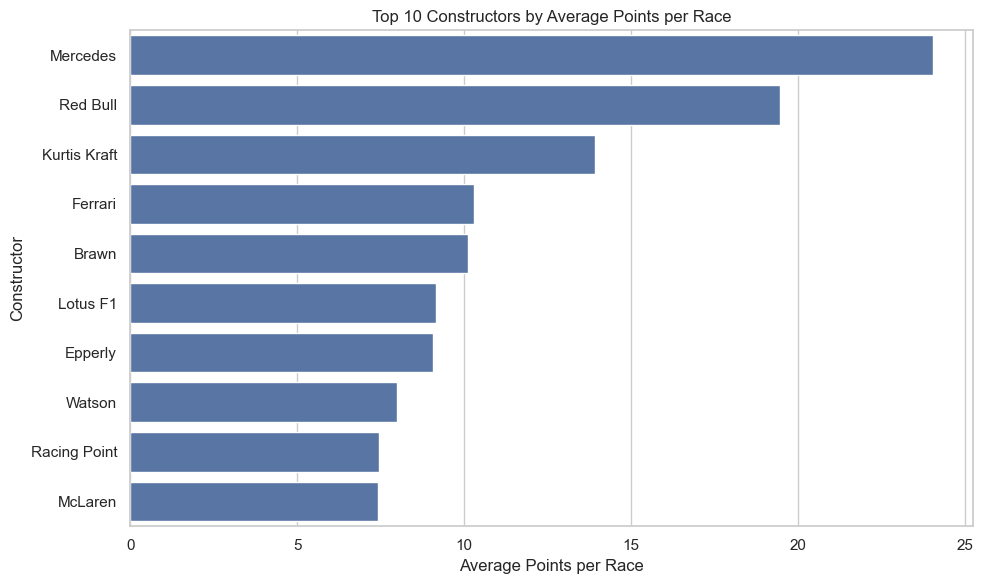

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=constructor_points.head(10),
    x="avgPoints",
    y="constructorName"
)

plt.title("Top 10 Constructors by Average Points per Race")
plt.xlabel("Average Points per Race")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()